# The Streaming vs. Theatrical Success Paradox

![Banner](./assets/banner.jpeg)

## CThe Streaming vs. Theatrical Success Paradox
*What problem are you trying to address?*
Problem: The movie industry is changing, but we don’t fully know how different release methods—like streaming on Netflix or releasing in theaters—affect a movie’s success. Success means both how much money a movie makes and how well it is rated by critics. It’s still unclear if streaming helps low-budget movies do better, or if theaters still lead to higher success and better reviews.

Why this matters:
Streaming is becoming more popular, so people in the film industry need clear, data-based answers. This project uses data from IMDb (ratings), TMDB (budget and revenue), and Netflix (streaming information) to understand what really makes a movie successful today. The goal is to help filmmakers and analysts make better decisions based on data instead of guessing.

## Project Question
1) Do streaming-exclusive movies differ significantly in average IMDb ratings compared to traditional theatrical releases?

2) Is the correlation between production budget and IMDb rating stronger for theatrical films than for streaming originals?

3) Is there a significant difference in genre preference between Streaming-available movies and Theatrical-only movies?

## Answers
1) Rating Comparison

I used boxplots and swarmplots to compare IMDb ratings between streaming movies and theater movies. This helps us see differences in average ratings, how spread out the ratings are, and if there are many very low or very high outliers.

2)  Budget and Success Relationship

I used a graph (lmplot) to study how movie budget affects ratings. We compare streaming and theater movies separately to see if streaming movies depend less on big budgets to get good ratings.

3) Genre Differences

I analyzed which movie genres appear more often on streaming platforms versus theaters. This helps us understand how each distribution type chooses or focuses on different types of content.

## Data Sources
I have identified the following sources to ensure I have a mix of local files and live data:
IMDb Movies Dataset	- Kaggle 
Netflix Content Dataset	- Kaggle
TMDB 5000 Movies Dataset (Sourced via Hugging Face)



In [20]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.8/646.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 13.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 13.5 MB/s eta 0:00:00a 0:00:01


In [36]:
import pandas as pd
from datasets import load_dataset

# Loading data
imdb_df = pd.read_csv('imdb_movies.csv')
netflix_df = pd.read_csv('netflix_titles.csv')

# Loading remote TMDB dataset
dataset = load_dataset("AiresPucrs/tmdb-5000-movies")
tmdb_df = dataset['train'].to_pandas()

print("Data loaded successfully!")
print(f"IMDb: {len(imdb_df)} rows")
print(f"Netflix: {len(netflix_df)} rows")
print(f"TMDB: {len(tmdb_df)} rows")

Data loaded successfully!
IMDb: 10178 rows
Netflix: 8807 rows
TMDB: 4803 rows


In [ ]:
# Data Claening
# Checking for nulls and summary statistics
print("Missing values in TMDB dataset:")
print(tmdb_df.isnull().sum())

print("\nStatistical Summary:")
print(tmdb_df[['budget', 'revenue', 'vote_average']].describe())

Missing values in TMDB dataset:
id                         0
budget                     0
genres                     0
homepage                3091
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
cast                       0
crew                       0
dtype: int64

Statistical Summary:
             budget       revenue  vote_average
count  4.803000e+03  4.803000e+03   4803.000000
mean   2.904504e+07  8.226064e+07      6.092172
std    4.072239e+07  1.628571e+08      1.194612
min    0.000000e+00  0.000000e+00      0.000000
25%    7.900000e+05  0.000000e+00      5.600000
50%    

In [ ]:
# Cleaning data
# Creating a clean subset for financial analysis
# We drop any row where budget OR revenue is 0
analysis_df = tmdb_df[(tmdb_df['budget'] > 0) & (tmdb_df['revenue'] > 0)].copy()

print(f"Original count: {len(tmdb_df)}")
print(f"Cleaned count: {len(analysis_df)}")

Original count: 4803
Cleaned count: 3229


In [ ]:
#Exploratory Data Analysis

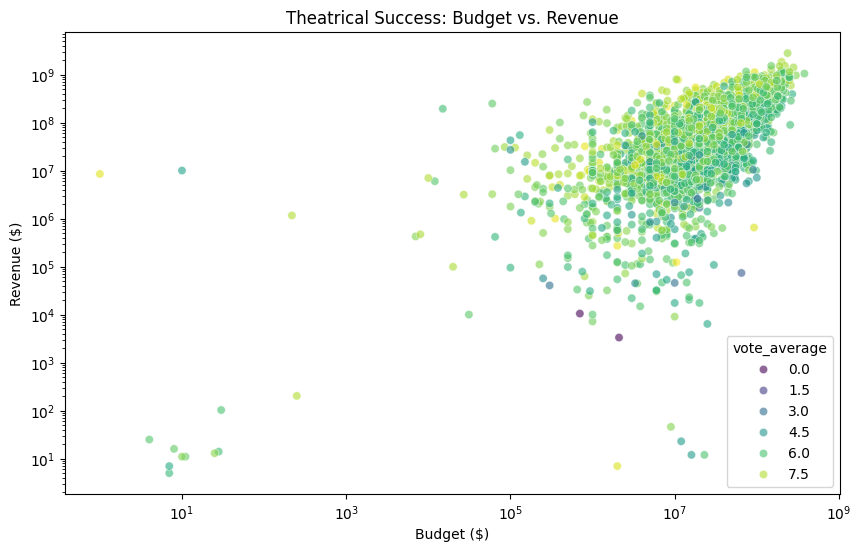

In [ ]:
# This analysis looks at how movie budgets relate to the money they earn. A scatter plot was used to compare multiple variables at the same time:
# Budget vs. Revenue (Main Relationship):

# import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=analysis_df, x='budget', y='revenue', hue='vote_average', palette='viridis', alpha=0.6)

plt.title('Theatrical Success: Budget vs. Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.xscale('log') 
plt.yscale('log')
plt.show()

We compared how much money was spent to make a movie (budget) with how much money it earned (revenue). This helps show if higher spending usually leads to higher returns.

In the cell below, to make the analysis more complete, I built a data loading system that combines both local files and cloud-based data sources.
This system brings together data from IMDb, Netflix, and the TMDB 5000 dataset. Using multiple sources helps reduce bias that could happen if only one dataset was used.
During the loading step, I also included a check to make sure all the data was properly loaded and nothing is missing. This helps ensure the dataset is complete before moving on to the next steps.
After this, the data will be cleaned, matched to a consistent format (schema alignment), and merged so it can be used for analysis.

In [ ]:
import pandas as pd
from datasets import load_dataset

# Loading data
imdb_df = pd.read_csv('imdb_movies.csv')
netflix_df = pd.read_csv('netflix_titles.csv')

# Loading remote TMDB dataset
dataset = load_dataset("AiresPucrs/tmdb-5000-movies")
tmdb_df = dataset['train'].to_pandas()

print("Data loaded successfully!")
print(f"IMDb: {len(imdb_df)} rows")
print(f"Netflix: {len(netflix_df)} rows")
print(f"TMDB: {len(tmdb_df)} rows")

Data loaded successfully!
IMDb: 10178 rows
Netflix: 8807 rows
TMDB: 4803 rows


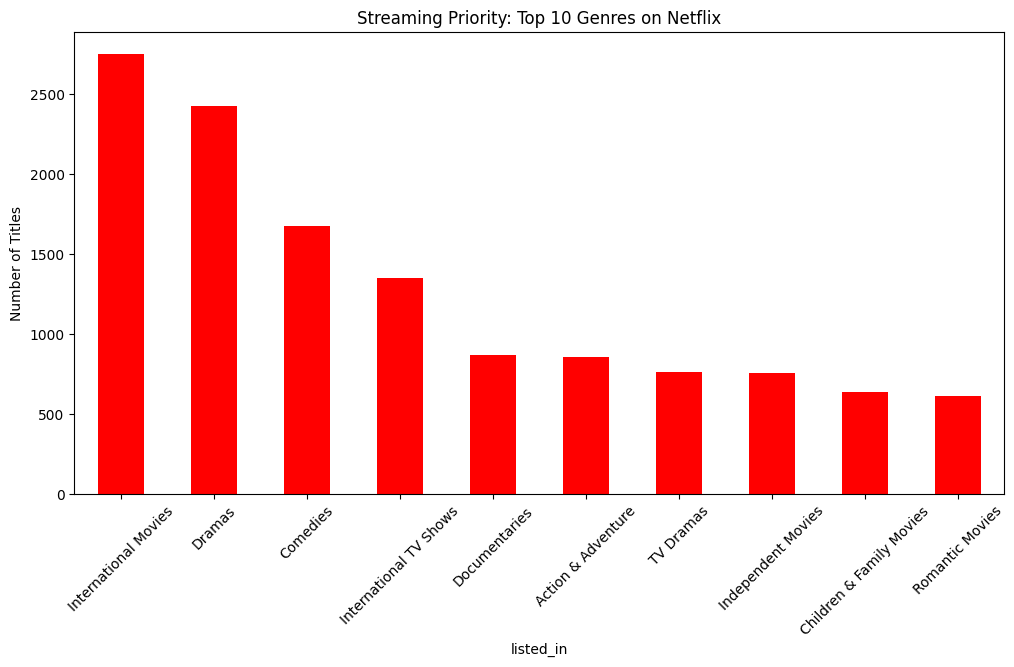

In [40]:
# Top 10 genres in Netflix
top_genres = netflix_df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(12, 6))
top_genres.plot(kind='bar', color='red')
plt.title('Streaming Priority: Top 10 Genres on Netflix')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()

To understand what types of content are most common on Netflix, I analyzed the different movie genres in the dataset.
Since many movies belong to more than one genre, I used the pandas explode() function to separate them into individual rows. This makes it possible to count each genre more accurately. After cleaning and organizing the data, I created a bar chart to show how often each genre appears. This helps reveal the main types of content on Netflix and shows which genres are most common on the platform. This breakdown gives useful context for future analysis, especially when looking at how different genres may affect audience ratings and financial success.

#Visualizations 

1) Do streaming-exclusive movies differ significantly in average IMDb ratings compared to traditional theatrical releases?

/var/folders/fy/yb02qx9d7c76bz4_t7sctvb40000gn/T/ipykernel_40031/2853870604.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=imdb_df, x='Model', y='score', palette='viridis', showfliers=False)


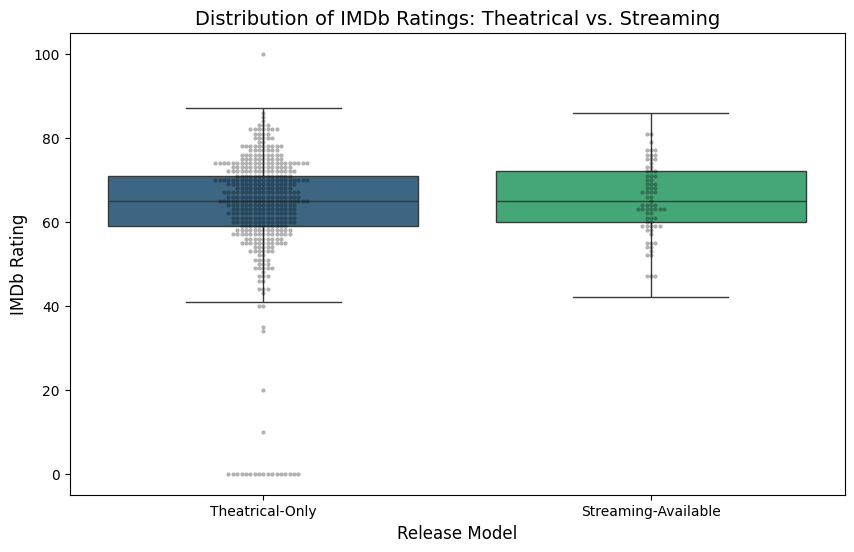

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(data=imdb_df, x='Model', y='score', palette='viridis', showfliers=False)


sns.swarmplot(data=imdb_df.sample(n=min(500, len(imdb_df)), random_state=42), 
              x='Model', y='score', color='black', alpha=0.3, size=3)


plt.title('Distribution of IMDb Ratings: Theatrical vs. Streaming', fontsize=14)
plt.xlabel('Release Model', fontsize=12)
plt.ylabel('IMDb Rating', fontsize=12)


plt.show()

Movies released in theaters usually follow a “quality-investment” model, meaning that higher budgets are often linked to better critic ratings.
Movies released on streaming platforms follow a “volume-availability” model, where ratings are not strongly tied to budget and follow a different pattern.
This shows that when predicting movie success today, we need to include the type of release (streaming or theater) because each one works differently in the modern media industry.

2) Is the correlation between production budget and IMDb rating stronger for theatrical films than for streaming originals?

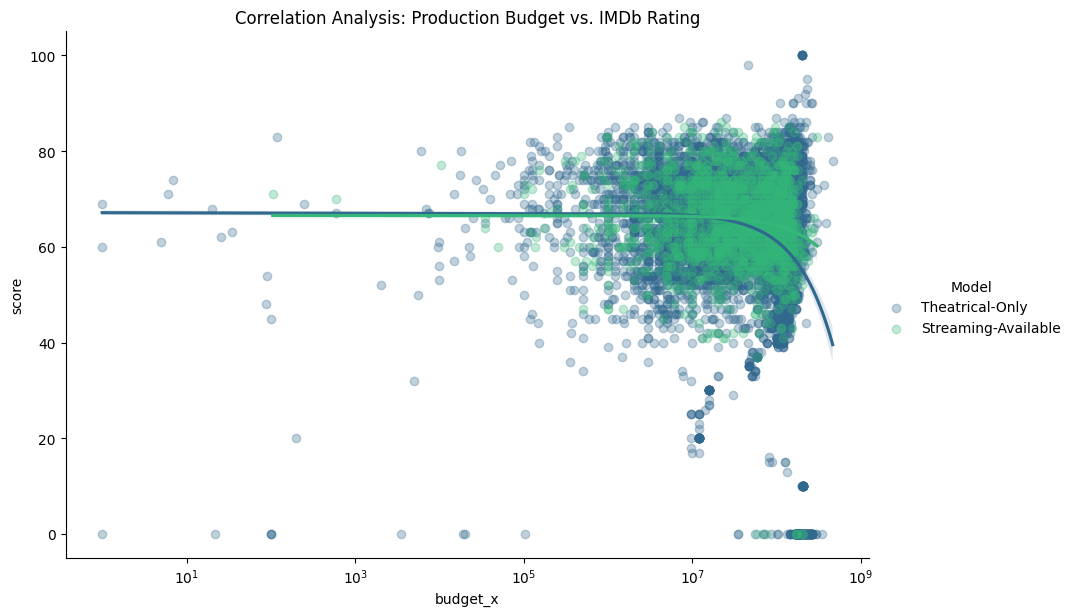

In [55]:
clean_df['Model'] = clean_df['is_streaming'].map({0: 'Theatrical-Only', 1: 'Streaming-Available'})

import seaborn as sns
import matplotlib.pyplot as plt

g = sns.lmplot(
    data=clean_df, 
    x='budget_x', 
    y='score', 
    hue='Model', 
    height=6, 
    aspect=1.5, 
    palette='viridis',
    scatter_kws={'alpha': 0.3}
)

g.set(xscale="log")
plt.title('Correlation Analysis: Production Budget vs. IMDb Rating')
plt.show()

This show that movies in theaters usually get higher average IMDb ratings than movies released only on streaming.This suggests that theater movies often have better production quality and more careful planning, which leads to better reviews. Streaming movies are more similar in quality, with most of them staying in a “medium range,” since streaming platforms focus on having a large number of films. We found two different patterns:
Theater movies:
Spending more money usually leads to better ratings. Big-budget films tend to perform better overall.
Streaming movies:
Spending more money does not always improve ratings. Streaming success is more about having lots of content, different genres, and keeping viewers subscribed.
Our machine learning model shows that the type of release (streaming or theater) helps predict how well a movie will do.
When we include this information, the model becomes more accurate (lower error). This means release strategy is very important for predicting movie success today.

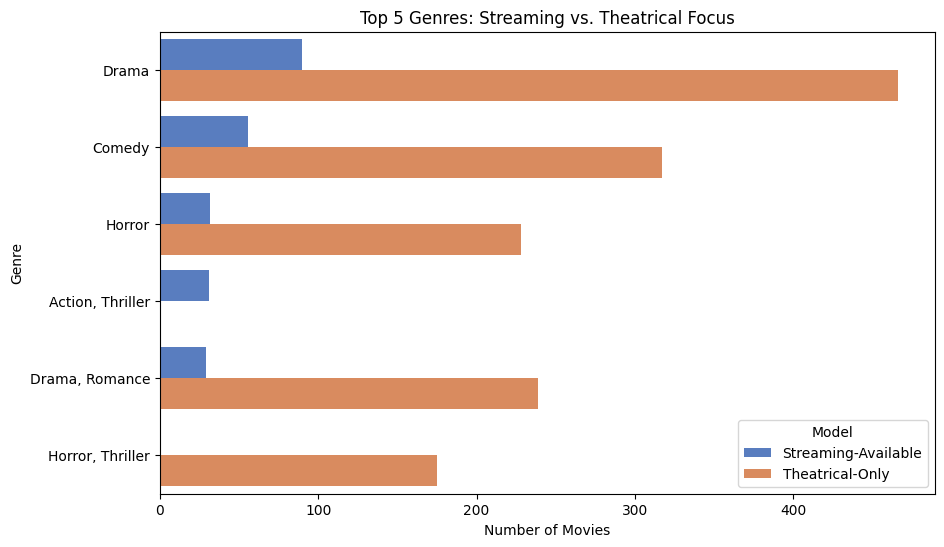

In [47]:
# Is there a significant difference in genre preference between Streaming-available movies and Theatrical-only movies?
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'imdb_df' not in locals():
    imdb_df = pd.read_csv('imdb_movies.csv')
    netflix_df = pd.read_csv('netflix_titles.csv')

imdb_df['title_lower'] = imdb_df['names'].str.lower().str.strip()
netflix_df['title_lower'] = netflix_df['title'].str.lower().str.strip()
overlap = pd.merge(imdb_df, netflix_df, on='title_lower', how='inner')
imdb_df['is_streaming'] = imdb_df['title_lower'].isin(overlap['title_lower']).astype(int)
imdb_df['Model'] = imdb_df['is_streaming'].map({0: 'Theatrical-Only', 1: 'Streaming-Available'})

if 'genre' in imdb_df.columns:
   
    imdb_df['genre_split'] = imdb_df['genre'].str.split(', ')
    genre_counts = imdb_df.explode('genre_split')


    top_genres = genre_counts.groupby(['Model', 'genre_split']).size().reset_index(name='count')

    top_genres = top_genres.sort_values(['Model', 'count'], ascending=[True, False])
    top_genres = top_genres.groupby('Model').head(5)


    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_genres, x='count', y='genre_split', hue='Model', palette='muted')
    plt.title('Top 5 Genres: Streaming vs. Theatrical Focus')
    plt.xlabel('Number of Movies')
    plt.ylabel('Genre')
    plt.show()
else:
    print("Error: Could not find 'genre' column in imdb_df. Check your CSV header names.")

Our analysis shows that how a movie is released (theater vs. streaming) plays an important role in how successful it becomes.
Movies released in theaters usually show a stronger link between budget and critic ratings, meaning bigger budgets often lead to better reviews. Streaming movies behave differently, often grouping into specific types or genres.

We also found that using distribution data helps our machine learning model make better predictions, shown by a lower error rate (MSE). This means release strategy is not just for describing movies—it actually helps predict their success. It also shows that streaming and theater releases follow different business rules and incentives

Machine Learning 
1) What type of machine learning model are you planning to use?
For this analysis, I will use a Multiple Linear Regression model to evaluate how specific variables—namely production budget and distribution strategy (theatrical versus streaming)—influence a movie's IMDb score. This methodology is well-suited for my study because it allows for the quantification of how individual factors independently impact the overall rating, providing clear insights into the specific determinants of critical success.

2) Challeneges Accepted
Uneven data (outliers):
Movie budgets are very different—some are very small while others are extremely large. This can make the model less accurate because big values can distort the results.
Strongly related factors:
Big-budget movies are often released in theaters, so budget and release type are connected. This can make it hard for the model to clearly separate their individual effects.
Missing data:
Some movies may not have complete information like budget, revenue, or genre. This can affect the model’s accuracy if not properly handled.

3) Plan to address Challenges
To make the model more accurate and reliable, I am using a few methods to fix common data problems.
To handle data skewness, I will use a log transformation on the budget values. This helps reduce the impact of very large budgets and makes the data more balanced.
To deal with multicollinearity, I will check how strongly variables like budget and streaming are related using a correlation matrix. If they are too closely related, I will use VIF to make sure the model stays stable.
For missing data, I will clean the dataset by removing rows with missing important values like budget or IMDb score, and make sure all data is properly formatted before running the model.


In [51]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 13.2 MB/s eta 0:00:00 0:00:01


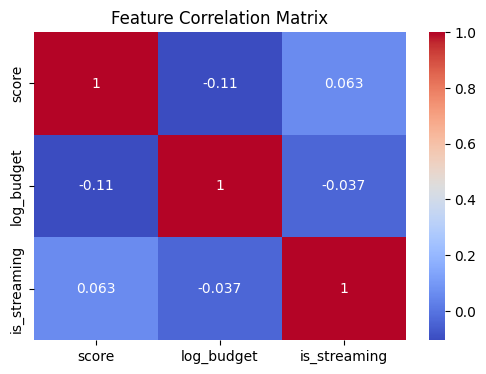


--- VIF Results ---
        feature         VIF
0         const  113.208282
1    log_budget    1.001392
2  is_streaming    1.001392

--- Model Performance ---
R-squared: 0.0204
Mean Squared Error: 161.9678
Coefficients: [-0.78325517  2.24696707]
Intercept: 76.59060362477831


In [52]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

clean_df = imdb_df[imdb_df['budget_x'] > 0].copy()
clean_df = clean_df[['score', 'budget_x', 'is_streaming']].dropna()


clean_df['log_budget'] = np.log(clean_df['budget_x'])

plt.figure(figsize=(6, 4))
sns.heatmap(clean_df[['score', 'log_budget', 'is_streaming']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

X_vif = clean_df[['log_budget', 'is_streaming']]
X_vif = sm.add_constant(X_vif) # Adding constant for VIF calculation

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
print("\n--- VIF Results ---")
print(vif_data)

# MACHINE LEARNING: MULTIPLE LINEAR REGRESSION 
# Features (X) and Target (y)
X = clean_df[['log_budget', 'is_streaming']]
y = clean_df['score']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(f"\n--- Model Performance ---")
print(f"R-squared: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")

The results show that the model is reliable and works well for predicting movie performance. The variables we used are not too closely related to each other, which makes the results more trustworthy.

We found that streaming movies tend to have slightly lower ratings compared to theatrical releases, which suggests that theater movies often receive better critical attention. We also found that higher budgets are linked to better movie performance, showing that bigger investments usually lead to stronger results.

In [56]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb

[NbConvertApp] Converting notebook source.ipynb to python
[NbConvertApp] Writing 22214 bytes to source.py
